c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\DELL\AppData\Local\Temp\ipykernel_2600\1612754529.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_2600\1612754529.py:26: FutureWarning: A value is tryi


🔹 Extra Trees for Conductivity Regression Metrics:
R²: 0.9711
RMSE: 0.0451
MAE: 0.0370
MAPE: 0.06%


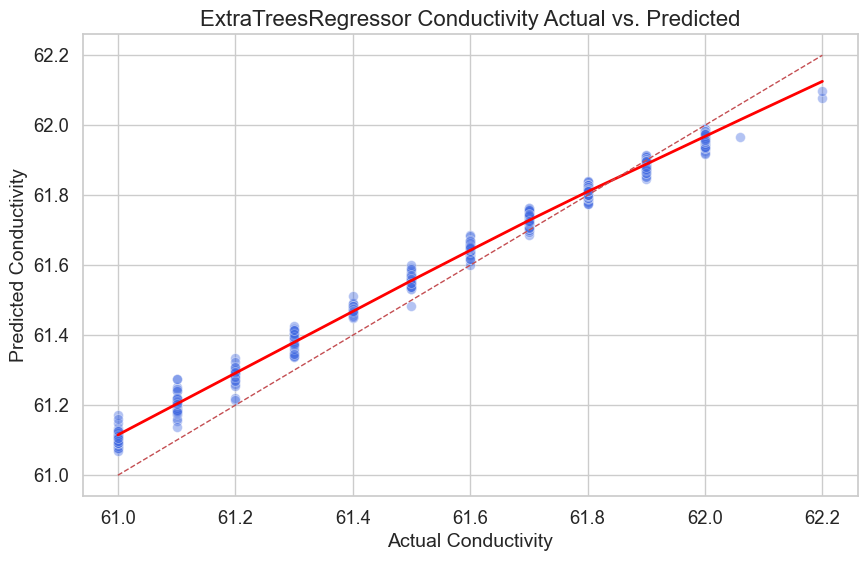

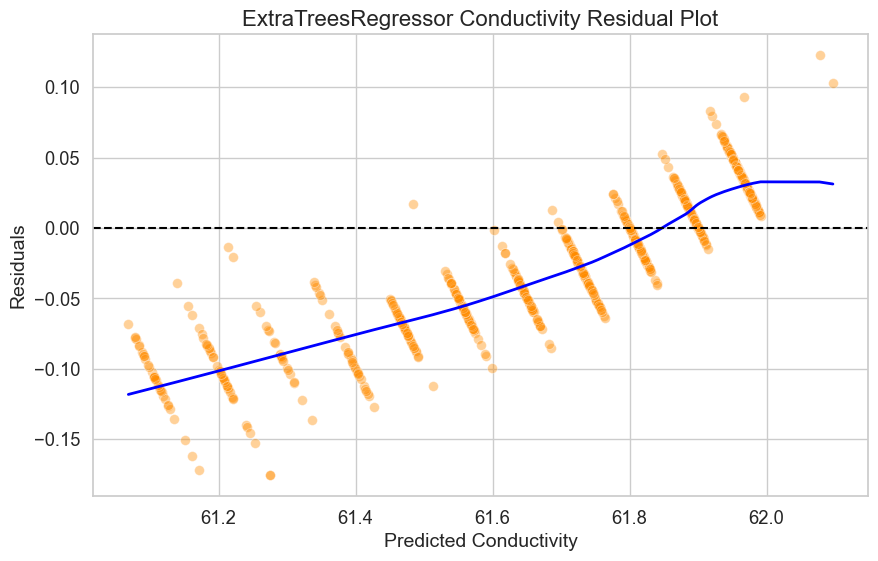

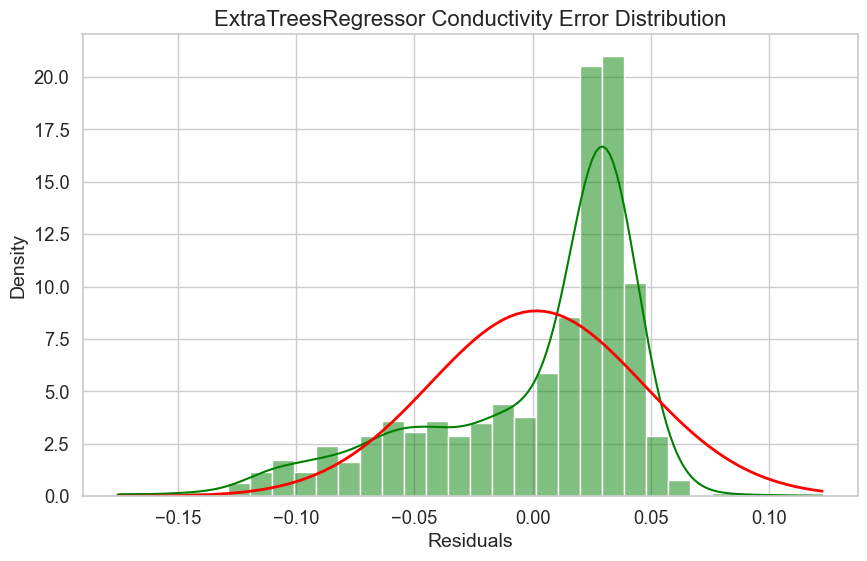

C:\Users\DELL\AppData\Local\Temp\ipykernel_2600\1612754529.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")


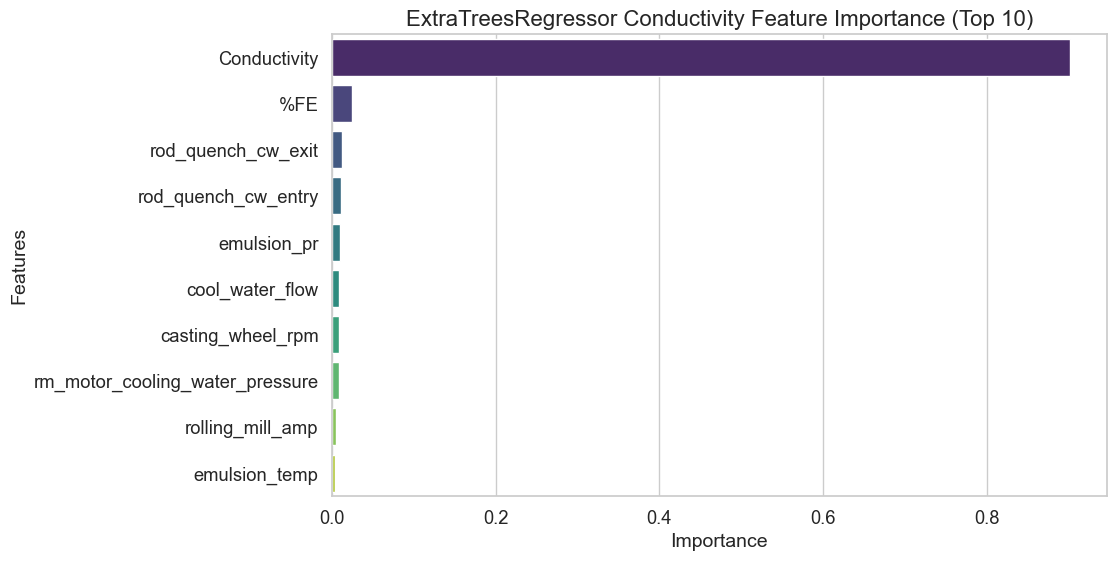

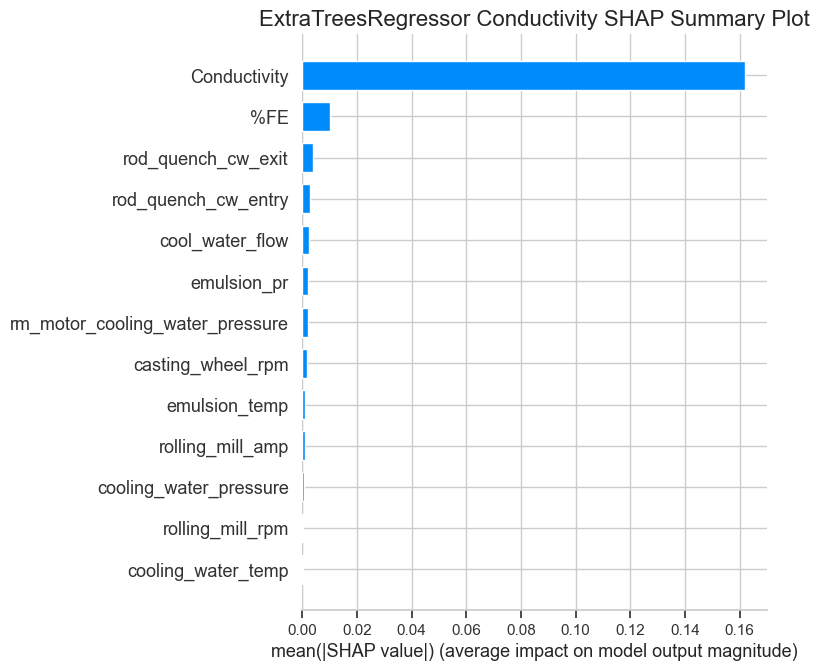

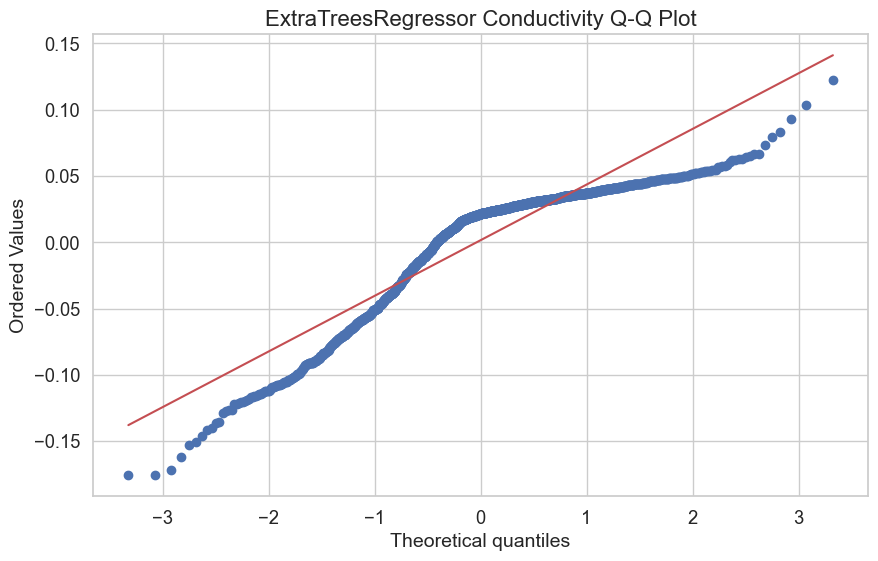

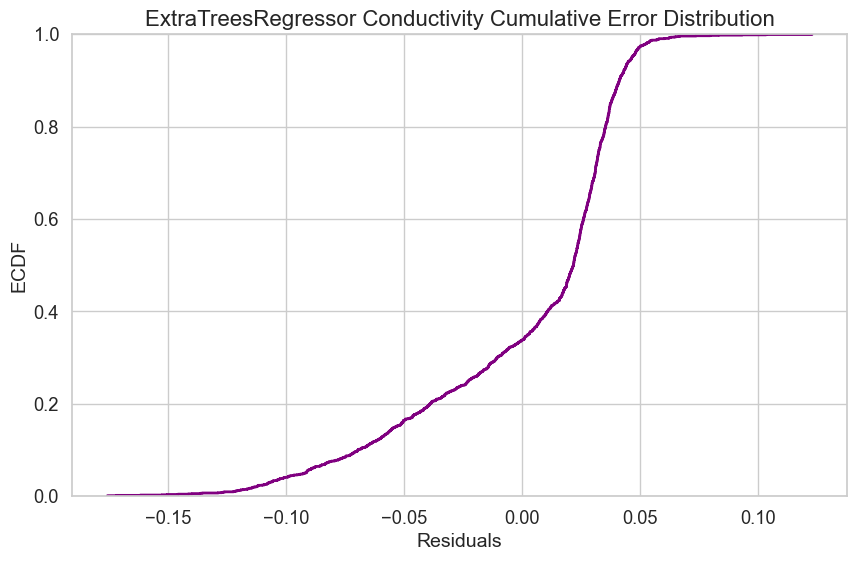

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df = df.drop_duplicates()

# ✅ Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ✅ Define columns to exclude
columns_to_exclude = ["UTS", "elongation", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["Conductivity"]  # Target variable Conductivity

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define Extra Trees hyperparameters
params_conductivity = {
    "n_estimators": 250,  # More trees for better generalization
    "max_depth": 12,  # Moderate depth to prevent overfitting
    "min_samples_split": 4,  # Minimum samples required to split a node
    "min_samples_leaf": 2,  # Minimum samples at a leaf node
    "max_features": "sqrt",  # Uses square root of total features
    "bootstrap": False,  # No bootstrapping in Extra Trees
    "random_state": 42,
    "n_jobs": -1  # Utilizes all CPU cores
}

# ✅ Train Extra Trees model for Conductivity
et_model_conductivity = ExtraTreesRegressor(**params_conductivity)
et_model_conductivity.fit(X_train, y_train)

# ✅ Predictions
y_test_pred = et_model_conductivity.predict(X_test)

# ✅ Compute Final R² Score and Extra Metrics
r2 = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 Extra Trees for Conductivity Regression Metrics:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# ✅ Visualizations
output_dir = "extratreesregressor_conductivity_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs Predicted Scatter Plot with LOESS curve
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("ExtraTreesRegressor Conductivity Actual vs. Predicted")
plt.xlabel("Actual Conductivity")
plt.ylabel("Predicted Conductivity")
plt.savefig(f"{output_dir}/ETR_Conductivity_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("ExtraTreesRegressor Conductivity Residual Plot")
plt.xlabel("Predicted Conductivity")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/ETR_Conductivity_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("ExtraTreesRegressor Conductivity Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/ETR_Conductivity_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Feature Importance Plot
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": et_model_conductivity.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
plt.title("ExtraTreesRegressor Conductivity Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir}/ETR_Conductivity_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. SHAP Summary Plot
explainer = shap.TreeExplainer(et_model_conductivity)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("ExtraTreesRegressor Conductivity SHAP Summary Plot")
plt.savefig(f"{output_dir}/ETR_Conductivity_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("ExtraTreesRegressor Conductivity Q-Q Plot")
plt.savefig(f"{output_dir}/ETR_Conductivity_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("ExtraTreesRegressor Conductivity Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/ETR_Conductivity_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

### ExtraTreesRegressor and RandomForestRegressor Do Not Track Performance During Training:
# that's why no learing curve for both
Both ExtraTreesRegressor and RandomForestRegressor are based on the bagging technique, where multiple trees are trained independently and in parallel. These models do not track validation performance during the training of each individual tree, unlike boosting models like XGBoost or LightGBM, which build trees sequentially and evaluate performance after each tree.

This parallel training means you cannot automatically track performance metrics like RMSE during training, which is why learning curves for these models are harder to generate without manual intervention.

Misleading Learning Curves:

The learning curve plot you showed is misleading because it tracks performance over different numbers of trees, but RandomForestRegressor and ExtraTreesRegressor only evaluate performance after the entire model (with all trees) is trained.

The model's performance is not updated after each tree, so the learning curve does not reflect the actual progress in learning as trees are added one by one.

Solution for Accurate Learning Curves:

To generate an accurate learning curve for RandomForestRegressor or ExtraTreesRegressor, you need to manually train the model incrementally by adding more trees and tracking performance after each iteration.

This approach involves training the model with different numbers of trees (e.g., 10, 50, 100, etc.) and computing the performance (like RMSE or R²) for each stage. This method would give a true representation of how the model improves as more trees are added.